# Contextual bandits

Imagine you open a video platform for the first time. The platform has to choose a channel to place in front of you, but it knows nothing about your tastes.

It does not know what you watched, what you skipped, or what you liked. This is the **cold-start problem**.

Suppose the catalog contains only five channels: **Technology**, **Sports**, **Cuisine**, **Car**, and **Art**. Which one should appear first?

We will let a small simulator play the role of the users. It will give us ratings, and we will use those ratings to improve our recommendation little by little.

## The global average: one answer for everyone

### a. Let's make a first guess

Let us start by assuming we have no information about the new user. We do, however, have a history from other users. A reasonable first move is to recommend the channel that receives the highest rating on average.

This gives us a useful first rule. It also makes a strong assumption: the same channel should be best for everyone.

### b. Let's see what our simulator knows

Before calculating anything, let's look at one interaction, to understand how our user-simulator works. For the sake of this lesson, it plays the role of users in the real world: it gives a user a country, a time of day, and a device, then generates a rating for one channel. In a real recommendation system, those details would come from the user request and the rating from an interaction such as a click, a watch, or a purchase.

In [1]:
from simulated_user import Item, ItemTitle, random_user, rate_item

user = random_user()
item = Item(ItemTitle.SPORTS)
rating = rate_item(user, item)

print(f"User country: {user.nationality.value}")
print(f"Time of day: {user.time_of_day.value}")
print(f"Device: {user.device_type.value}")
print(f"Item: {item.title.value}")
print(f"Rating: {rating}/5")

User country: UK
Time of day: evening
Device: desktop
Item: Sports
Rating: 3/5


### c. Let's try the rule

The output is one possible interaction: a user, a channel, and a rating.

One interaction tells us almost nothing. In real life, we would use past interactions. Here, we will simulate that history by asking many users to rate each channel, then calculate the average.

In [2]:
N = 10_000
avg_rating_by_item = {
    item.value: sum(rate_item(random_user(), Item(item)) for _ in range(N))/N
    for item in ItemTitle
}
print(avg_rating_by_item)

{'Technology': 3.3251, 'Sports': 3.4558, 'Cuisine': 3.2659, 'Car': 3.1719, 'Art': 3.1073}


After generating a history, we can compare the channels. Sports has the highest average in this simulation, so our first recommender will always show Sports.

We have learned one number per channel. Let's see how this rule behaves on new users: what average rating will we obtain by always showing the best channel ?

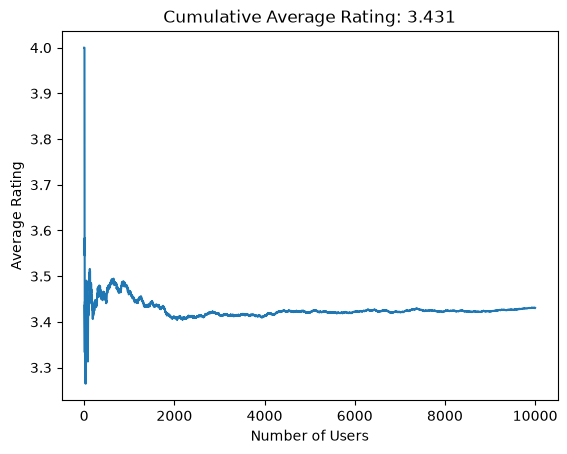

In [3]:
import matplotlib.pyplot as plt

def reco_for_user(user=None):
	return Item(ItemTitle.SPORTS)

total_rating = 0
cumulative_ratings = []
for user_index in range(10_000):
	user = random_user()
	total_rating += rate_item(user, reco_for_user(user))
	cumulative_ratings.append(total_rating / (user_index + 1))

plt.plot(cumulative_ratings)
plt.xlabel("Number of Users")
plt.ylabel("Average Rating")
plt.title("Cumulative Average Rating: {:.3f}".format(cumulative_ratings[-1]))
plt.show()

It is a useful baseline, but it still ignores the person who is looking at the screen. Why can't we use the user's characteristics to provide a better recommendation ? 

## A group average: one answer for each country

### a. Let's use the information we already have

Sports is the best channel when we mix everyone together. But perhaps it is not the best channel for every country. We already know the user's nationality in our simulator, so let's use it.

Instead of asking "Which channel is best for everybody?", we can ask a more useful question: "Which channel is best for users from this country?"

### b. Let's stop mixing everybody together

We are going to stop putting every rating in the same pile. We will make one pile for each nationality, then compare the channels inside the matching pile.

For a French user, for example, the estimate for the *Cuisine* channel will use ratings from French users, not ratings from the whole world. This is still an average, but it is now a **group average**.

There is a price to pay. Each pile contains fewer ratings than the global one, so the estimates become less certain.

### c. Let's build the country table

Let's build these piles from a small history of interactions. For every country, we will keep the channel with the highest average rating, then use that channel when a new user arrives.

In [4]:
# Building the dict {Nationality: {ItemTitle: ratings}} from historical interactions
import random

N = 1000
all_ratings = {}
for _ in range(N):
    user = random_user()
    item = Item(random.choice(tuple(ItemTitle)))
    rating = rate_item(user, item)
    all_ratings.setdefault(user.nationality, {}).setdefault(item.title, []).append(rating)

# Aggregating and selecting the item with the highest average rating for each country
popular_item_by_country = {
    country: max(items, key=lambda item: sum(items[item]) / len(items[item]))
    for country, items in all_ratings.items()
}
print(popular_item_by_country)

def reco_for_user(user):
    return Item(popular_item_by_country[user.nationality])

{<Nationality.FR: 'FR'>: <ItemTitle.CUISINE: 'Cuisine'>, <Nationality.UK: 'UK'>: <ItemTitle.SPORTS: 'Sports'>, <Nationality.US: 'US'>: <ItemTitle.SPORTS: 'Sports'>, <Nationality.DE: 'DE'>: <ItemTitle.CAR: 'Car'>, <Nationality.JP: 'JP'>: <ItemTitle.TECHNOLOGY: 'Technology'>}


Great ! We have learned which channel performs best per country. Let's see how this rule behaves on new users: what average rating will we obtain by always showing the best channel for each country ?

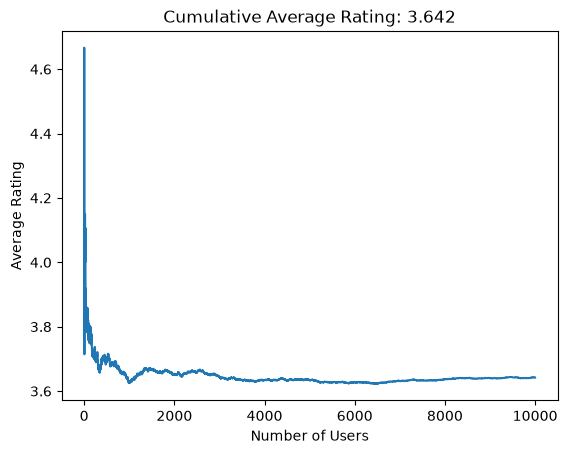

In [5]:
total_rating = 0
cumulative_ratings = []
for user_index in range(10_000):
	user = random_user()
	total_rating += rate_item(user, reco_for_user(user))
	cumulative_ratings.append(total_rating / (user_index + 1))

plt.plot(cumulative_ratings)
plt.xlabel("Number of Users")
plt.ylabel("Average Rating")
plt.title("Cumulative Average Rating: {:.3f}".format(cumulative_ratings[-1]))
plt.show()

The group result is already more interesting: two users from different countries can receive different channels.

But nationality is only one clue. The simulator also knows the time of day and the device being used. A French user in the morning on a phone may not want the same thing as a French user in the evening on a desktop computer.

## A tabular contextual bandit: one answer for each situation

### a. Let's build the context key

Why not use the complete situation as the key: nationality, time of day, and device? We can keep one average for each context and channel. A French user in the morning on a mobile device can then have a different favourite channel from a French user in the evening on a desktop computer.

### b. What does the bandit table contain?

Let us make the table concrete. In this small simulator there are already 5 x 3 x 2 = 30 possible contexts. With five channels, the table stores 150 context/channel estimates. A real service can have far more context, and many entries would remain almost empty.

This is a **tabular contextual bandit**: the context is the user's nationality, time of day, and device; the action is the channel we choose; and the reward is the resulting rating. The table stores historical rewards for each context/action pair, so we can estimate which channel is best for a new user in that context.

The table can be populated from historical interactions, exactly as in the previous examples, or updated as new recommendations produce feedback. Its limitation is that every new context needs its own estimates, so the table grows quickly and each entry receives less data.

### c. How does the bandit balance exploration and exploitation?

At each decision, the bandit faces an **exploration-exploitation trade-off**. **Exploitation** means choosing the channel with the highest estimated rating: it uses what the bandit already knows and usually gives a good immediate result. **Exploration** means trying another channel, even when its current estimate is lower or still unknown: it may reduce the immediate rating, but it produces information and can reveal a better channel.

The epsilon-greedy rule makes this compromise explicit. First, every channel gets one chance for the current context. After that, the bandit explores randomly with probability `epsilon` and exploits its current best estimate otherwise. With `epsilon = 0.1`, it explores 10% of the time and exploits 90% of the time.

### d. Let's implement and evaluate the bandit

The code below implements the mechanism described above. It keeps two numbers for every context/channel pair: how many times the channel was shown, and the sum of the ratings it received.

We could fill this table from historical interactions, as in the previous examples. Here, we start with an empty table and update it after each recommendation to demonstrate the online loop. The current user provides the context, the recommender chooses a channel, the simulator returns that channel's rating, and the table is updated.

In [6]:
from collections import defaultdict

items = tuple(ItemTitle)
epsilon = 0.1
counts = defaultdict(lambda: defaultdict(int))
reward_totals = defaultdict(lambda: defaultdict(float))


def estimated_reward(user, item):
    if counts[user][item] == 0:
        return 0.0
    return reward_totals[user][item] / counts[user][item]


def reco_for_user(user):
    unexplored_items = [item for item in items if counts[user][item] == 0]

    if unexplored_items:
        chosen_item = unexplored_items[0]
    elif random.random() < epsilon:
        chosen_item = random.choice(items)
    else:
        chosen_item = max(items, key=lambda item: estimated_reward(user, item))

    return Item(chosen_item)


def update_bandit(user, item, rating):
    counts[user][item.title] += 1
    reward_totals[user][item.title] += rating

The functions above define how the bandit chooses and updates a channel. It has not learned anything yet. Let's let it serve 10,000 users and give each rating back to the bandit immediately.

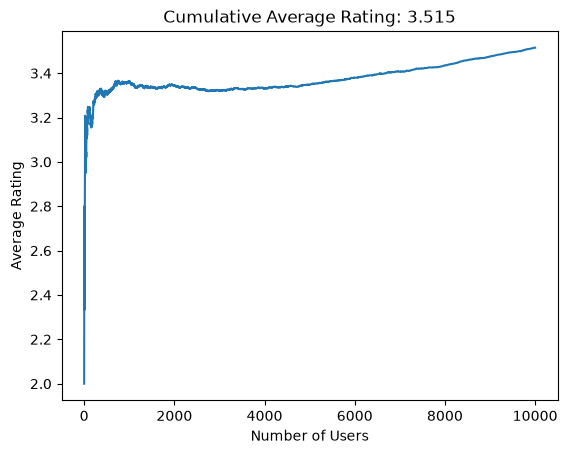

In [7]:
counts.clear()
reward_totals.clear()

total_rating = 0
cumulative_ratings = []
for user_index in range(10_000):
    user = random_user()
    item = reco_for_user(user)
    rating = rate_item(user, item)
    update_bandit(user, item, rating)
    total_rating += rating
    cumulative_ratings.append(total_rating / (user_index + 1))

plt.plot(cumulative_ratings)
plt.xlabel("Number of Users")
plt.ylabel("Average Rating")
plt.title("Cumulative Average Rating: {:.3f}".format(cumulative_ratings[-1]))
plt.show()

The table works well here because the number of possible contexts is small. But a larger recommendation system may know a user's language, location, subscription, recent history, device, and many other things. A separate average for every combination would need an enormous table. It would also need much more examples to correctly estimates the rating for each of the "groups" constituting one of the "contexts". 

What would happen if we encounter a context for which we have no data ? Our table system is not able to generalize ! 

## A linear model: learning from features

### a. What if the table is too big ?



And what if the system could learn that some contexts are related? A French user in the morning and a French user in the evening are not the same context, but they still share the fact that they are French. A model can use these shared pieces of information, if there is not enough data to go the the lowest granularity.

Using linear models to predict the expected reward for each potential arm, based on features, is exactly the idea behind contextual bandits.

### b. How can a model share information?

A linear model does not store one average for every exact situation. It predicts the expected rating for each potential item, given the features (the context) of the user. Concretely, it means building as many linear models as there are options (items), and predicting the rating for each channel as follows:

$$
\widehat{r}(user, item) = \theta_{item}^{\mathsf{T}} x(user)
$$

With $x$ being the features we know from the user, and $\theta$ the values learned from past interactions.

### c. Let's build the model

Each item has its own parameter vector $\theta_{item}$. It has one coefficient for each feature. If we put all these parameter vectors together, they form an $n_{items} \times n_{features}$ coefficient matrix. The code keeps them separately because each item receives different ratings.

For one item, suppose we have observed users with feature vectors $x_1, x_2, \ldots, x_n$ and ratings $r_1, r_2, \ldots, r_n$. We want the coefficients that make the predictions as close as possible to those ratings:

$$
\theta_{item} = \arg\min_{\theta} \sum_{j=1}^{n} \left(r_j - \theta^{\mathsf{T}} x_j\right)^2
$$

Solving this least-squares problem gives the normal equation:

$$
\left(\sum_{j=1}^{n} x_j x_j^{\mathsf{T}}\right) \theta_{item}
= \sum_{j=1}^{n} r_j x_j
$$

This is why the code keeps two objects per item:

- `matrices[item]` is $A_{item} = \sum_j x_j x_j^{\mathsf{T}}$, an $n_{features} \times n_{features}$ matrix.
- `vectors[item]` is $b_{item} = \sum_j r_j x_j$, an $n_{features}$-value vector.

When a new rating $r$ arrives for features $x$, its contribution is added to both sums:

$$
A_{item} \leftarrow A_{item} + xx^{\mathsf{T}},
\qquad
b_{item} \leftarrow b_{item} + rx
$$

The model stores the current solution in `weights[item]`. It solves $A_{item}\theta_{item} = b_{item}$ once after each update, so prediction only needs a dot product. It still keeps $A_{item}$ and $b_{item}$ because the next rating must be added to those accumulated sums; the weights alone are not enough. The identity matrix used to initialize $A_{item}$ is a small regularization that keeps the system solvable before any ratings arrive.

In [8]:
import random

import numpy as np


class LinearBandit:
    def __init__(self, items, n_features, epsilon=0.1):
        self.items = tuple(items)
        self.epsilon = epsilon
        self.matrices = {item: np.eye(n_features) for item in self.items}
        self.vectors = {item: np.zeros(n_features) for item in self.items}
        self.weights = {item: np.zeros(n_features) for item in self.items}

    def predict(self, features, item):
        return float(self.weights[item] @ features)

    def choose(self, features):
        if random.random() < self.epsilon:
            return random.choice(self.items)
        return max(self.items, key=lambda item: self.predict(features, item))

    def update(self, features, item, rating):
        self.matrices[item] += np.outer(features, features)
        self.vectors[item] += rating * features
        self.weights[item] = np.linalg.solve(self.matrices[item], self.vectors[item])

### d. Let's train and evaluate the model

Now the bandit serves 10,000 users, updates after each rating, plots its average rating, and predicts the best channel for a French user in the morning on a mobile device.

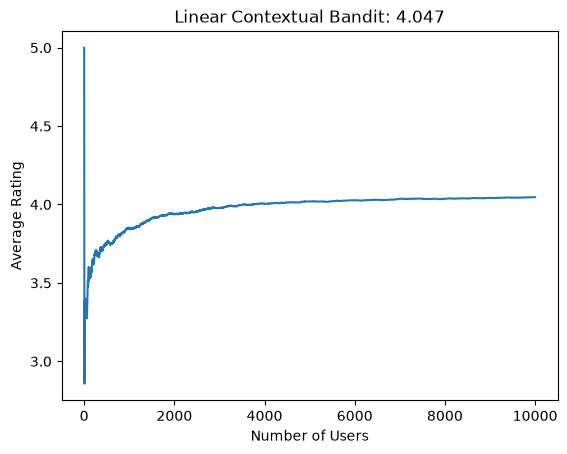

In [9]:
import matplotlib.pyplot as plt
from simulated_user import User, user_to_features


random.seed(21)
n_features = len(user_to_features(random_user()))
bandit = LinearBandit(items, n_features)
total_rating = 0
cumulative_ratings = []
for user_index in range(10_000):
    user = random_user()
    user_features = user_to_features(user)
    item = bandit.choose(user_features)
    rating = rate_item(user, Item(item))
    bandit.update(user_features, item, rating)
    total_rating += rating
    cumulative_ratings.append(total_rating / (user_index + 1))

plt.plot(cumulative_ratings)
plt.xlabel("Number of Users")
plt.ylabel("Average Rating")
plt.title("Linear Contextual Bandit: {:.3f}".format(cumulative_ratings[-1]))
plt.show()

That is the main advantage of the linear contextual bandit. We no longer need to keep one completely separate average for every possible situation. The user is described by features, and the model learns how those features influence the reward of each channel. A French user in the morning and a French user in the evening are not treated as complete strangers: they still share the information that they are French. The model can reuse that information when there are only a few observations for one exact context.

Of course, this is not magic. The features must be useful, and the relationship between the features and the reward must be reasonably linear. But this is already a big improvement over a table that can only remember situations it has seen before.

## In summary

We started with a simple question: which channel should we show to a new user?

First, we chose the channel with the best average rating. This gave us a useful baseline, but it also gave the same answer to everybody. Then we used the user's country, and finally the complete context. Each step made the recommendation more personal.

There was a catch, though. The more we split users into groups, the fewer examples we had in each group. A table that stores one estimate for every exact situation becomes difficult to fill, and it has nothing useful to say about a situation it has never seen.

The linear contextual bandit gives us a way around this problem. Instead of memorizing every situation separately, it learns from the features that make up the situation. It can reuse what it learned from related users and contexts. The important thing to remember is this: adding context is useful only if we also have a way to share information between contexts. Otherwise, the table quickly becomes too big and too empty.

That is what we have built in this notebook: we started with an average, added context, discovered the data-sparsity problem, and then used a model that can generalize. The linear model is not the final answer to every recommendation problem, but it gives us a clear next step. We can now ask which features are useful, what happens when rewards are not linear, and how the bandit should choose between trying a new channel and using the best one it knows.